In [1]:
# ¿Qué evolución de la primera ola colombiana puede reproducir un modelo SIR básico a partir de los casos confirmados reportados?

# Los diagnósticos reportados no son infecciones reales; se usa una ventana de 14 días como aproximación didáctica de casos activos.

import numpy as np
import pandas as pd

daily_cases = pd.read_csv("../data/colombia_daily_cases.csv.gz", compression="gzip", parse_dates=["date"])
first_wave = daily_cases.loc[
    daily_cases["date"].between("2020-03-06", "2020-06-30")
].copy()
first_wave = first_wave.set_index("date").asfreq("D", fill_value=0).reset_index()
first_wave["active_cases_proxy"] = first_wave["daily_cases"].rolling(14, min_periods=1).sum()
observed = first_wave.rename(columns={"active_cases_proxy": "active_cases"})[["date", "active_cases"]]
observed["day"] = np.arange(len(observed))
observed.tail()

,date,active_cases,day
112,2020-06-26,39217.0,112
113,2020-06-27,41271.0,113
114,2020-06-28,42840.0,114
115,2020-06-29,43330.0,115
116,2020-06-30,43146.0,116


In [2]:
# Se implementa un SIR con fallecimientos que conserva la población de Colombia.

population = 50_372_424
recovery_rate = 0.08
death_rate = 0.0
reference_capacity = 10_000


def simulate_sir(infection_rate, initial_infected, forecast_days):
    susceptible, infected, recovered, deceased = (
        population - initial_infected,
        initial_infected,
        0.0,
        0.0,
    )
    records = []
    for day in range(forecast_days):
        records.append(
            {
                "day": day,
                "susceptible": susceptible,
                "infected": infected,
                "recovered": recovered,
                "deceased": deceased,
            }
        )
        new_infections = infection_rate * infected * susceptible / population
        new_recoveries = recovery_rate * infected
        new_deaths = death_rate * infected
        susceptible -= new_infections
        infected += new_infections - new_recoveries - new_deaths
        recovered += new_recoveries
        deceased += new_deaths
    return pd.DataFrame(records)

In [3]:
# ¿Qué tasa constante reproduce mejor los casos activos disponibles hasta hoy?

initial_infected = observed.loc[0, "active_cases"]
fit_comparison = []
for infection_rate in np.round(np.arange(0.10, 0.41, 0.01), 2):
    simulation = simulate_sir(infection_rate, initial_infected, len(observed))
    fit_comparison.append(
        {
            "infection_rate": infection_rate,
            "observed_mse": (
                (simulation["infected"] - observed["active_cases"]) ** 2
            ).mean(),
        }
    )
fit_comparison = pd.DataFrame(fit_comparison)
baseline_rate = fit_comparison.loc[
    fit_comparison["observed_mse"].idxmin(), "infection_rate"
]
baseline_rate

0.18

In [4]:
# Se proyectan escenarios de transmisión sin seleccionar una política óptima.

scenarios = {
    "transmision_actual": baseline_rate,
    "transmision_moderada": baseline_rate * 0.75,
    "transmision_alta": baseline_rate * 1.15,
}
forecasts = []
for scenario, infection_rate in scenarios.items():
    simulation = simulate_sir(infection_rate, initial_infected, 180)
    simulation["scenario"] = scenario
    simulation["infection_rate"] = infection_rate
    simulation["required_beds"] = simulation["infected"] * 0.05
    forecasts.append(simulation)
forecasts = pd.concat(forecasts, ignore_index=True)
forecasts.head()

,day,susceptible,infected,recovered,deceased,scenario,infection_rate,required_beds
0,0,5.037242e+07,1.0000,0.00000,0.0,transmision_actual,0.18,0.050000
1,1,5.037242e+07,1.1000,0.08000,0.0,transmision_actual,0.18,0.055000
2,2,5.037242e+07,1.2100,0.16800,0.0,transmision_actual,0.18,0.060500
3,3,5.037242e+07,1.3310,0.26480,0.0,transmision_actual,0.18,0.066550
4,4,5.037242e+07,1.4641,0.37128,0.0,transmision_actual,0.18,0.073205


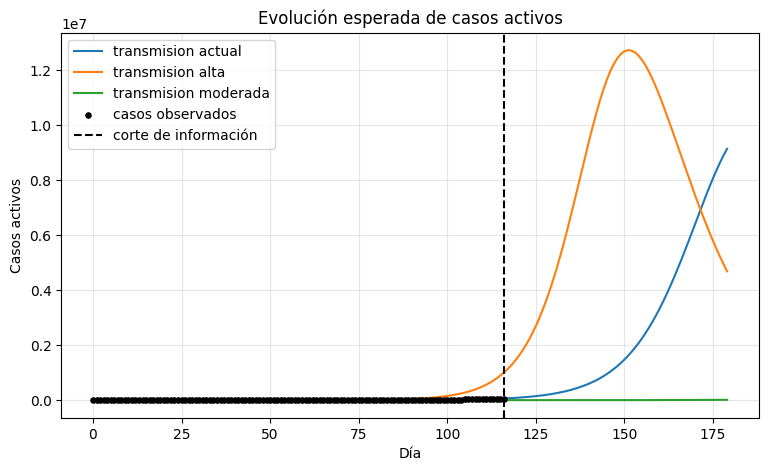

In [5]:
# ¿Cómo evolucionan los casos activos esperados después del corte de información?

import matplotlib.pyplot as plt

figure, axis = plt.subplots(figsize=(9, 5))
for scenario, scenario_forecast in forecasts.groupby("scenario"):
    axis.plot(
        scenario_forecast["day"],
        scenario_forecast["infected"],
        label=scenario.replace("_", " "),
    )
axis.scatter(
    observed["day"],
    observed["active_cases"],
    color="black",
    s=14,
    label="casos observados",
    zorder=3,
)
axis.axvline(
    observed["day"].max(), color="black", linestyle="--", label="corte de información"
)
axis.set(
    title="Evolución esperada de casos activos", xlabel="Día", ylabel="Casos activos"
)
axis.grid(alpha=0.3)
axis.legend()
plt.show()

In [6]:
# ¿En qué día ocurre el pico y cuántas camas se requieren en cada escenario?

bed_capacity = 1_500
scenario_peaks = forecasts.loc[
    forecasts.groupby("scenario")["infected"].idxmax()
].copy()
scenario_peaks = scenario_peaks[
    ["scenario", "infection_rate", "day", "infected", "required_beds"]
].rename(
    columns={
        "day": "peak_day",
        "infected": "peak_active_cases",
        "required_beds": "peak_required_beds",
    }
)
scenario_peaks["bed_capacity"] = bed_capacity
scenario_peaks["bed_gap"] = scenario_peaks["peak_required_beds"] - bed_capacity
scenario_peaks

,scenario,infection_rate,peak_day,peak_active_cases,peak_required_beds,bed_capacity,bed_gap
179,transmision_actual,0.180,179,9.144041e+06,457202.064193,1500,455702.064193
511,transmision_alta,0.207,151,1.273016e+07,636507.915882,1500,635007.915882
359,transmision_moderada,0.135,179,1.450360e+04,725.179845,1500,-774.820155


In [7]:
# Se conservan pronósticos, la gráfica, los picos y los supuestos para verificar el escenario construido.

import json
from pathlib import Path

submission_dir = Path("../submission")
forecasts.to_csv(submission_dir / "forecasts.csv", index=False)
figure.savefig(submission_dir / "expected_evolution.png", dpi=150, bbox_inches="tight")
scenario_peaks.to_csv(submission_dir / "scenario_peaks.csv", index=False)
fit_comparison.to_csv(submission_dir / "fit_comparison.csv", index=False)
with (submission_dir / "model_assumptions.json").open("w", encoding="utf-8") as file:
    json.dump(
        {
            "population": population,
            "observation_cutoff_day": int(observed["day"].max()),
            "forecast_days": 180,
            "recovery_rate": recovery_rate,
            "death_rate": death_rate,
            "hospitalization_rate": 0.05,
            "reference_capacity": reference_capacity,
            "baseline_infection_rate": baseline_rate,
        },
        file,
        indent=2,
    )